**<span style="color: green;">MINI_PROJETO AVALIATIVO - Análise Exploratória de Dados com Python**

*Curso:* Análise de Dados com Python [T2] | Módulo 1 - Semana 07 | 
*Aluno:* Lucas Lidnei Rodrigues

Mini-Projeto Avaliativo da matéria de Manipulação de Dados com Python e SQL. 
Será realizada a identificação da qualidade dos dados, tratamento dos problemas identificados através de ferramentas como pandas e gerar estísticas simples e funções de agrupamento para responder perguntas operacionais.

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


**<span style="color: green;">[Sprint 1] Importação dos dados**

Leitura e analise da base de dados analisada com pandas

In [2]:
# Carga dos dados na planilha Base_varejo_raw.csv
df_base_varejo = pd.read_csv('../data/Base_varejo_raw.csv', sep=';', encoding='utf-8')

print('Dados carregados com sucesso!')

Dados carregados com sucesso!


In [3]:
# Exibição da tabela de dados e suas primeiras linhas, para compreensção de sua estrutura e conteúdo
print('Exibindo as primeiras 5 linhas da base de dados:')
df_base_varejo.head(5)

Exibindo as primeiras 5 linhas da base de dados:


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


In [4]:
# Verificação de informações como número de linhas, colunas, tipos de dados e presença de valores nulos
print('Informações sobre a base de dados:')
df_base_varejo.info()

Informações sobre a base de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  object 
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  object 
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  object 
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  object 
 9   PR_NOME      830000 non-null  object 
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), object(5)
memory usage: 88.7+ MB


In [5]:
# Validação de valores nulos por coluna
print('Valores nulos por coluna:')
df_base_varejo.isnull().sum()

Valores nulos por coluna:


DATA                0
CO_ID               0
CL_ID               0
CL_GENERO           0
CL_EC               0
CL_FHL              0
CL_SEG              0
PR_ID               0
PR_CAT              0
PR_NOME             0
Unnamed: 10    830000
Unnamed: 11    830000
Unnamed: 12    830000
Unnamed: 13    830000
dtype: int64

**<span style="color: green;">[Sprint 2] Tratamento dos dados - Transformação de Strings, Integer e Float e Datetime**

Tratamento dos dados para garantir uma base com dados adequados, evitando problemas na analise dos dados

In [6]:

# Primeiro será realizada a cópia da base original para manter os dados raw sem alterações
df_base_varejo_limpa = df_base_varejo.copy()

# Remoção das colunas Unnamed 10 até 13, pois não possueem informações
df_base_varejo_limpa.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'], inplace=True)

# Converter coluna DATA de String para Datetime
df_base_varejo_limpa['DATA'] = pd.to_datetime(df_base_varejo_limpa['DATA'], format='%d/%m/%Y', errors='coerce')

# Converter colunas numéricas para números inteiros
df_base_varejo_limpa['CO_ID'] = df_base_varejo_limpa['CO_ID'].astype(int)   # Idenfiticação da compra
df_base_varejo_limpa['CL_ID'] = df_base_varejo_limpa['CL_ID'].astype(int)   # Identificação do cliente
df_base_varejo_limpa['PR_ID'] = df_base_varejo_limpa['PR_ID'].astype(int)   # Identificação do produto
df_base_varejo_limpa['CL_EC'] = df_base_varejo_limpa['CL_EC'].astype(int)   # Identificação do estado civil do cliente (código)
df_base_varejo_limpa['CL_FHL'] = df_base_varejo_limpa['CL_FHL'].astype(int) # Identificação do número de filhos do cliente

# Padronizar colunas de string, convertendo para letras minúsculas e removendo espaços em branco extras.
for col in ['CL_GENERO', 'CL_SEG', 'PR_CAT', 'PR_NOME']:
  df_base_varejo_limpa[col] = (
    df_base_varejo_limpa[col]
    .astype(str) # Garantir que a coluna seja do tipo string
    .str.strip() # Remover espaços em branco no início e no final
    .str.replace(r'\s+', ' ', regex=True)  # Arrumar espaços duplos
    .str.upper() # Converter para letras maiúsculas
  )

# Impressões para validar se todas as alterações foram realizadas adequadamente
print(df_base_varejo_limpa.head(1))
print(f'\n Tipos de dados após tratamento:')
print(df_base_varejo_limpa.dtypes.to_string())
print(f'\n Valores nulos por coluna após tratamento: \n {df_base_varejo_limpa.isnull().sum()}')
print(f'\n Datas invalidas (NaT) detectadas após tratamento: {df_base_varejo_limpa["DATA"].isna().sum()}')

        DATA  CO_ID  CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG  PR_ID   PR_CAT  \
0 2019-02-01   1000    534         M      4       1      C     67  BEBIDAS   

                PR_NOME  
0  REFRIGERANTE GUARANA  

 Tipos de dados após tratamento:
DATA         datetime64[ns]
CO_ID                 int64
CL_ID                 int64
CL_GENERO            object
CL_EC                 int64
CL_FHL                int64
CL_SEG               object
PR_ID                 int64
PR_CAT               object
PR_NOME              object

 Valores nulos por coluna após tratamento: 
 DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

 Datas invalidas (NaT) detectadas após tratamento: 0


**<span style="color: green;">[Sprint 3] Limpeza de nulos e duplicadas**

Identificação de possíveis problemas na base de dados

In [7]:
# Identificação de possíveis problemas:

# Valores nulos
print(f'\n Valores nulos por coluna:')
nulos = df_base_varejo_limpa.isnull().sum()
print(nulos.to_string())

# Duplicados
duplicadas = df_base_varejo_limpa.duplicated().sum()
print(f'\n Número de linhas duplicadas: {duplicadas:,}'.replace(",", "."))

# Dados com categoria inválida
categoria_invalida = (df_base_varejo_limpa['PR_CAT'] == '#N/D').sum()
print(f'\n Registros com PR_CAT = #N/D: {categoria_invalida:,}'.replace(",", "."))


 Valores nulos por coluna:
DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0

 Número de linhas duplicadas: 96.553

 Registros com PR_CAT = #N/D: 3.650


Correção dos problemas identificados

In [8]:
# Remoção dos dados duplicados encontrados
df_base_varejo_limpa.drop_duplicates(inplace=True)

# Troca da categoria '#N/D' para 'NAO INFORMADA' na coluna 'PR_CAT'
df_base_varejo_limpa['PR_CAT'] = df_base_varejo_limpa['PR_CAT'].replace('#N/D', 'NAO INFORMADA')

print('Dados tratados com sucesso!')

Dados tratados com sucesso!


**<span style="color: green;">[Sprint 4] Estatística Descritiva**

Aplicação das funções estatísticas para coletar parâmetros da coluna de Número de filhos do cliente.

Na base os filhos estão contidos em todas as linhas de produtos, desta forma é preciso primeiro agrupar os clientes (coluna CL_ID) e depois fazer os cálculos estatísticos de filhos por cliente

In [9]:
# Tratamento do clientes duplicados (CL_ID)
filhos = df_base_varejo_limpa.drop_duplicates(subset=['CL_ID'])['CL_FHL']

# Validação estatística dos filhos por cliente
media = filhos.mean()
mediana = filhos.median()
moda = filhos.mode()[0]
desvio = filhos.std()
maximo = filhos.max()
minimo = filhos.min()
q1 = filhos.quantile(0.25)
q2 = filhos.quantile(0.5)
q3 = filhos.quantile(0.75)

print(f'Estatísticas dos filhos por cliente:')
print(f'Número de clientes únicos: {filhos.count():,}'.replace(",", "."))
print(f'Média: {media:.3f}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')
print(f'Desvio Padrão: {desvio:.3f}')
print(f'Mínimo: {minimo}')
print(f'Máximo: {maximo}')
print(f'1º Quartil: {q1}')
print(f'2º Quartil (Mediana): {q2}')
print(f'3º Quartil: {q3}')

Estatísticas dos filhos por cliente:
Número de clientes únicos: 1.000
Média: 1.136
Mediana: 0.0
Moda: 0
Desvio Padrão: 1.413
Mínimo: 0
Máximo: 4
1º Quartil: 0.0
2º Quartil (Mediana): 0.0
3º Quartil: 2.0


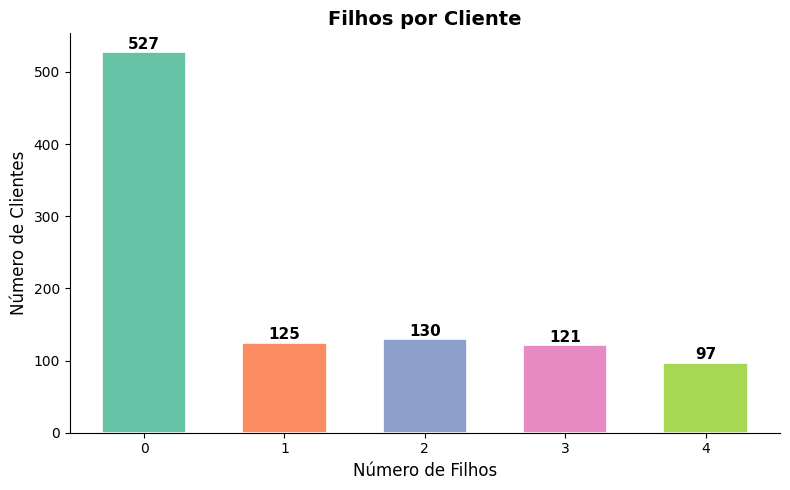

In [10]:
# Distribuição gráfica dos filhos por cliente
clientes = filhos.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
cores = sns.color_palette('Set2', n_colors=len(clientes))

barras = ax.bar(clientes.index.astype(int),  # categorias no eixo X
                clientes.values,   # valores no eixo Y
                color=cores,    # lista de cores (uma por barra)
                width=0.6,      # largura relativa das barras
                edgecolor='white',
                linewidth=1.2)

# Adicionando rótulo de valor em cima de cada barra
for barra in barras:
    # get_height() → pega o valor numérico que define a altura da barra
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,  # centro da barra no eixo X
        altura + 0.5,                             # um pouquinho acima da barra
        str(int(altura)),                         # texto: número de clientes
        ha='center',     # alinhamento horizontal centralizado
        va='bottom',     # alinhamento vertical: texto sobe a partir daqui
        fontweight='bold',
        fontsize=11
    )

ax.set_title("Filhos por Cliente", fontsize=14, fontweight='bold')
ax.set_xlabel("Número de Filhos", fontsize=12)
ax.set_ylabel("Número de Clientes", fontsize=12)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**<span style="color: green;">[Sprint 5] Relatório e Documentação**

In [11]:
# Agrupamento 1: Compras únicas realizadas por Gênero
ag_genero = (df_base_varejo_limpa.groupby('CL_GENERO')['CO_ID']
                .nunique()
                .reset_index()
                .rename(columns={'CO_ID': 'Quantidade de Itens'})
                .sort_values('Quantidade de Itens', ascending=False)
)
print(f'\n [1º Agrupamento] Total de itens comprados por Gênero: \n {ag_genero.to_string(index=False)}')
print(f'\n Total de compras únicas realizadas: {ag_genero["Quantidade de Itens"].sum()}')

# Agrupamento 2: Itens comprados por Categoria de Produto
ag_categoria = (df_base_varejo_limpa.groupby('PR_CAT')['CO_ID']
                 .count()
                 .reset_index()
                 .rename(columns={'CO_ID': 'Quantidade de Itens'})
                 .sort_values('Quantidade de Itens', ascending=False)
)
print(f'\n [2º Agrupamento] Total de itens comprados por Categoria de Produto: \n {ag_categoria.to_string(index=False)}')

# Agrupamento 3: Compras únicas realizadas por Segmento de Cliente
ordem_segmentos = ['A', 'B', 'C']
ag_segmento = (df_base_varejo_limpa.groupby('CL_SEG')['CO_ID']
                .nunique()
                .reset_index()
                .rename(columns={'CO_ID': 'Quantidade de Itens'})
                .sort_values('CL_SEG', key=lambda x: x.map({seg: i for i, seg in enumerate(ordem_segmentos)}))
)
print(f'\n [3º Agrupamento] Total de itens comprados por Segmento de Cliente: \n {ag_segmento.to_string(index=False)}')

# Agrupamento 4: Top 10 produtos mais comprados
ag_produtos = (df_base_varejo_limpa.groupby('PR_NOME')['CO_ID']
                .count()
                .reset_index()
                .rename(columns={'CO_ID': 'Quantidade de Itens'})
                .sort_values('Quantidade de Itens', ascending=False)
                .head(10)
)
print(f'\n [4º Agrupamento] Top 10 produtos mais comprados: \n {ag_produtos.to_string(index=False)}')


 [1º Agrupamento] Total de itens comprados por Gênero: 
 CL_GENERO  Quantidade de Itens
        F                 9615
        M                 8856

 Total de compras únicas realizadas: 18471

 [2º Agrupamento] Total de itens comprados por Categoria de Produto: 
        PR_CAT  Quantidade de Itens
    ALIMENTOS               384197
      HIGIENE               137702
      LIMPEZA               128632
      BEBIDAS                38264
          PET                28553
   ACESSORIOS                12871
NAO INFORMADA                 3228

 [3º Agrupamento] Total de itens comprados por Segmento de Cliente: 
 CL_SEG  Quantidade de Itens
     A                 1492
     B                11843
     C                 5136

 [4º Agrupamento] Top 10 produtos mais comprados: 
            PR_NOME  Quantidade de Itens
   PRESUNTO COZIDO                12719
          SARDINHA                 6610
            BANANA                 6518
   ESCOVA DE DENTE                 6518
               GE

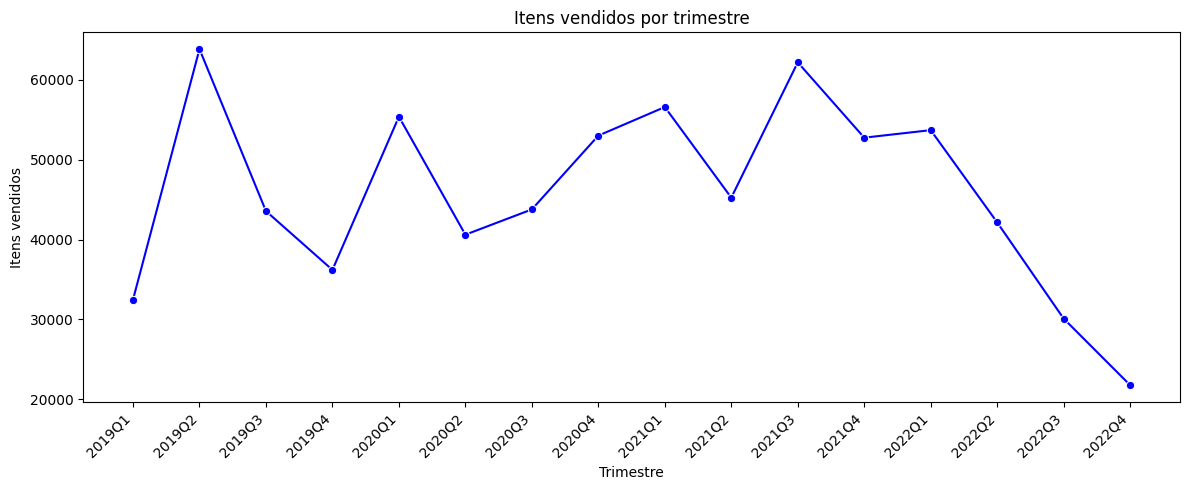

In [15]:
# Agrupamento 5: Vendas por trimestre
vendas_por_trimestre = (
    df_base_varejo_limpa.assign(TRIMESTRE=df_base_varejo_limpa["DATA"].dt.to_period("Q").astype(str))
    .groupby("TRIMESTRE")
    .agg(
        itens_vendidos=("PR_ID", "count"),
        compras_unicas=("CO_ID", "nunique"),
    )
    .reset_index()
)

vendas_por_trimestre.head()

plt.figure(figsize=(12, 5))
sns.lineplot(data=vendas_por_trimestre, x="TRIMESTRE", y="itens_vendidos", marker="o", color="#0000FF")
plt.title("Itens vendidos por trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Itens vendidos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

*Extração da base tratada para novo arquivo csv*

In [13]:
df_base_varejo_limpa.to_csv('../outputs/Base_varejo_limpa.csv', index=False, encoding='utf-8')

**<span style="color: green;">Conclusões Finais**

**PROBLEMAS CORRIGIDOR**
- A base bruta possuía **830.000 registros** e, após a limpeza, ficou com **733.447 registros** únicos;
- Foram removidos **96.533 mil registros duplicados** e **4 colunas sem dados**;
- Foram alterados **3.650 registros** que não possuíam descrição de produtos, destes **422** estavam duplicados;

**INFORMAÇÕES OBTIDAS**
- A base possui **18.471 compras unicas** feita por **1.000 clientes unicos**;
- O Gênero Feminino realizou **9.615** representando **52%** do total de compras. O Gênero Masculino realizou **8.856** representando **48%** do total de compras;
- A categoria com maior quantidade de itens vendidos foi **ALIMENTOS** com **384.197 itens**, seguida por **HIGIENE** com **137.702 itens** e **LIMPEZA** com **128.632 itens**;
- Os segmentos de clientes que mais realizam compras são **B** com **11.843 compras** realizadas, seguido pelo **C** com **5.136 compras**;
- A maioria dos clientes (527), não possuem ou não informaram ter filhos, tendo uma mediana de **0** filhos e uma média de **1,14** filhos;
- No período analisado é possível verificar sazionalidade nas vendas, com picos entre o final do 4º trimestre e inicio do 2º trimestre.
- A base não possui coluna de valor de venda, então impossibilitando análises sobre faturamento, ticket média, etc.

**SUGESTÕES**
- Recomenda-se tratar a base categorizando os 3.650 registro que não possuiam descrição;
- Recomenda-se incluir coluna com informações sobre o preço de venda, pois enriquecerá a análise dos dados e possibilitará mais insights relevantes para o negócio;
- Com base nos dados obitidos é possível traçar estratégias de marketing para segmentação por classe, gênero, filhos e itens vendidos.
- Com base nos dados de sazionalidade das vendas, pode-se aplicar politicas de abastecimento nos períodos com maior demanda.


